In [1]:
!pip install --upgrade -q kaggle
!pip install -q gdown
!pip install -q ultralytics

import torch
import os
from google.colab import userdata
import subprocess
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from ultralytics import YOLO
import glob
import numpy as np
from scipy.ndimage import gaussian_filter
import math
import pandas as pd

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 6.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


# ANÁLISE INICIAL E DOWNLOAD DOS ARQUIVOS

O intuito desta análise é olhar os dados e verificar quais passos de preprocessamento são necessários para conformar os dados para a CNN.

## VERIFICANDO .XML E .JPG

O intuito desta verificação é garantir que teremos os .xml para validar as métricas e os .jpg para classificação.

In [3]:
!kaggle datasets files bratjay/ua-detrac-orig

Next Page Token = CfDJ8ImuQD4OY2pEnVW2WQ-kgncjQlbfd1dQ_5dAaOUFc-fYAGVcujQULQ_S0d9Oqay2IXAoOsJbd5cwhANNfTcVgqmvz98LBo55upcjQv_SsAerzSRccktuNKotIfWqnjOK-jXEQQp7MjI5quPG_NpA8X28xjAUDOVjZAHo2HvpQXjC96Ox2yKKO4gomw
name                                                 size  creationDate                
--------------------------------------------------  -----  --------------------------  
DETRAC-Images/DETRAC-Images/MVI_20011/img00001.jpg  80170  2025-06-08 21:59:51.432000  
DETRAC-Images/DETRAC-Images/MVI_20011/img00002.jpg  81502  2025-06-08 21:59:51.432000  
DETRAC-Images/DETRAC-Images/MVI_20011/img00003.jpg  81683  2025-06-08 21:59:51.433000  
DETRAC-Images/DETRAC-Images/MVI_20011/img00004.jpg  81216  2025-06-08 21:59:51.426000  
DETRAC-Images/DETRAC-Images/MVI_20011/img00005.jpg  81321  2025-06-08 21:59:51.432000  
DETRAC-Images/DETRAC-Images/MVI_20011/img00006.jpg  81330  2025-06-08 21:59:51.418000  
DETRAC-Images/DETRAC-Images/MVI_20011/img00007.jpg  80843  2025-06-08 21:59:51.432000  

In [4]:
resultado = subprocess.run(
    ["kaggle", "datasets", "files", "bratjay/ua-detrac-orig"],
    capture_output=True, text=True
)
linhas = resultado.stdout.splitlines()

# procurar por .xml ou pastas de anotação
anotacoes = [l for l in linhas if ".xml" in l.lower() or "annotation" in l.lower()]
print(f"Total de linhas: {len(linhas)}")
print(f"Linhas com XML/annotation: {len(anotacoes)}")
for a in anotacoes[:10]:
    print(a)

Total de linhas: 23
Linhas com XML/annotation: 0


Download dos .xml


In [5]:
!gdown --id 12xJc8S0Z7lYaAadsi2CoSK3WqH2OkUBu -O DETRAC-Train-Annotations-XML.zip
!unzip -q DETRAC-Train-Annotations-XML.zip -d /content/detrac_annotations

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=12xJc8S0Z7lYaAadsi2CoSK3WqH2OkUBu
To: /content/DETRAC-Train-Annotations-XML.zip
100% 13.8M/13.8M [00:00<00:00, 51.8MB/s]


In [6]:
anotacoes = os.listdir("/content/detrac_annotations/DETRAC-Train-Annotations-XML")
print(f"Total de arquivos: {len(anotacoes)}")
print(anotacoes[:5])

Total de arquivos: 60
['MVI_39851.xml', 'MVI_40172.xml', 'MVI_63561.xml', 'MVI_39781.xml', 'MVI_40141.xml']


In [7]:
arquivos_mvi_20011 = [arquivo for arquivo in anotacoes if "MVI_20011" in arquivo]

for arquivo in arquivos_mvi_20011:
    print(arquivo)

MVI_20011.xml


Aqui o intuito é parsear o .xml para trabalhar estes dados.

In [8]:
def parse_detrac_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    anotacoes = {}
    for frame in root.findall("frame"):
        frame_num = int(frame.get("num"))
        boxes = []
        for target in frame.find("target_list").findall("target"):
            box = target.find("box").attrib
            tipo = target.find("attribute").attrib.get("vehicle_type", "unknown")
            boxes.append({
                "left": float(box["left"]),
                "top": float(box["top"]),
                "width": float(box["width"]),
                "height": float(box["height"]),
                "vehicle_type": tipo,
            })
        anotacoes[frame_num] = boxes
    return anotacoes

xml_path = "/content/detrac_annotations/DETRAC-Train-Annotations-XML/MVI_20011.xml"
anotacoes = parse_detrac_xml(xml_path)

print(f"Frames anotados: {len(anotacoes)}")
print(f"Exemplo (frame 1): {anotacoes[1]}")

Frames anotados: 664
Exemplo (frame 1): [{'left': 592.75, 'top': 378.8, 'width': 160.05, 'height': 162.2, 'vehicle_type': 'car'}, {'left': 557.65, 'top': 120.98, 'width': 47.2, 'height': 43.06, 'vehicle_type': 'car'}, {'left': 545.2, 'top': 88.27, 'width': 35.25, 'height': 30.08, 'vehicle_type': 'car'}, {'left': 508.35, 'top': 67.5, 'width': 28.0, 'height': 25.925, 'vehicle_type': 'car'}, {'left': 553.0, 'top': 70.095, 'width': 29.55, 'height': 19.695, 'vehicle_type': 'car'}, {'left': 731.1, 'top': 114.23, 'width': 52.4, 'height': 39.95, 'vehicle_type': 'car'}, {'left': 902.15, 'top': 250.12, 'width': 58.85, 'height': 107.99, 'vehicle_type': 'car'}]


Download dos .jpg

In [9]:
!kaggle datasets download -d bratjay/ua-detrac-orig
!unzip ua-detrac-orig.zip -d ua_detrac

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01214.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01215.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01216.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01217.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01218.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01219.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01220.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01221.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01222.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01223.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01224.jpg  
  inflating: ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554/img01225.jpg  
  inflating: ua_detrac/DETRAC

Verificação da compatibilidade entre as imagens e as anotações

In [10]:
img_dir = "/content/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20011"
n_imgs = len(os.listdir(img_dir))
n_frames_anotados = len(anotacoes)

print(f"Imagens: {n_imgs}")
print(f"Frames anotados: {n_frames_anotados}")
assert n_imgs == n_frames_anotados, "Contagem não bate — verificar sequência"

Imagens: 664
Frames anotados: 664


Validação das imagens e anotações.

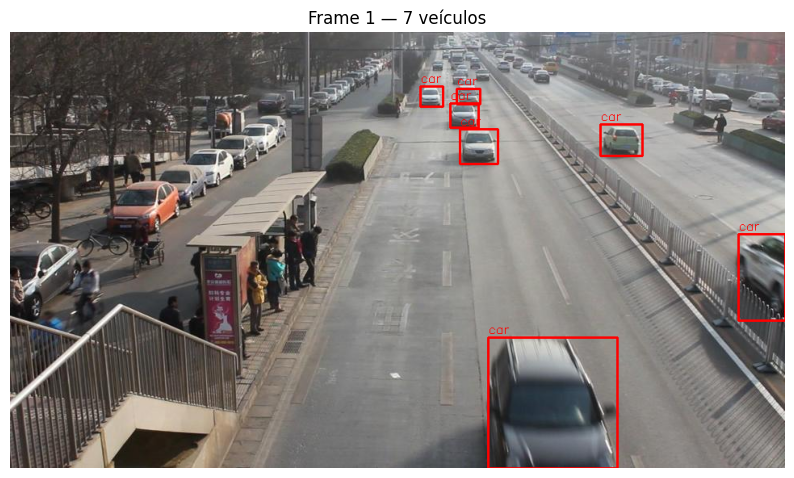

In [11]:
frame_num = 1
img_path = f"{img_dir}/img{frame_num:05d}.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for box in anotacoes[frame_num]:
    x, y, w, h = int(box["left"]), int(box["top"]), int(box["width"]), int(box["height"])
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(img, box["vehicle_type"], (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Frame {frame_num} — {len(anotacoes[frame_num])} veículos")
plt.show()

# Detecção com YOLO pré-treinado

In [12]:
model = YOLO("yolov8m.pt")  # medium, mais preciso que nano
model.to("cuda")

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_


image 1/1 /content/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20011/img00001.jpg: 736x1280 12 persons, 6 bicycles, 34 cars, 2 motorcycles, 1 train, 3 trucks, 72.7ms
Speed: 37.3ms preprocess, 72.7ms inference, 45.8ms postprocess per image at shape (1, 3, 736, 1280)


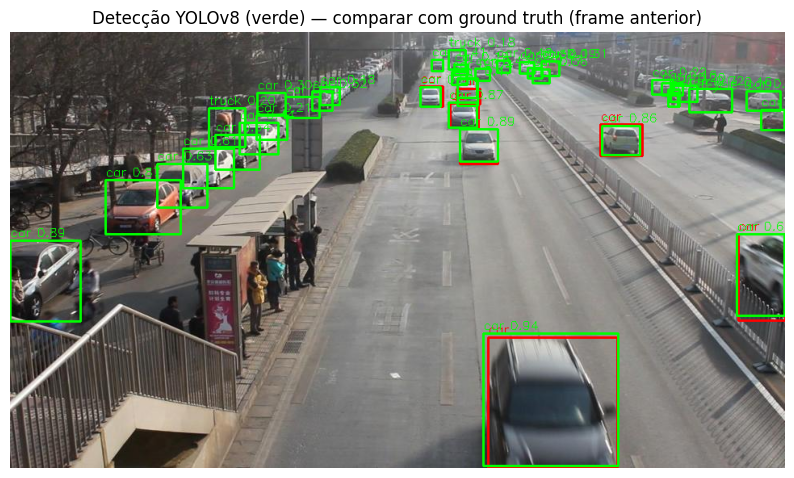

In [13]:
results = model(img_path, conf=0.15, imgsz=1280)
result = results[0]

classes_veiculo = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

img_pred = img.copy()
for box in result.boxes:
    cls_id = int(box.cls[0])
    if cls_id in classes_veiculo:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cv2.rectangle(img_pred, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img_pred, f"{classes_veiculo[cls_id]} {conf:.2f}",
                    (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(10, 6))
plt.imshow(img_pred)
plt.axis("off")
plt.title("Detecção YOLOv8 (verde) — comparar com ground truth (frame anterior)")
plt.show()

# Reconstrução do vídeo .mp4

In [14]:
img_dir = "/content/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20011"
output_path = "/content/sequencia_20011.mp4"

frames = sorted(glob.glob(f"{img_dir}/*.jpg"))
print(f"Total de frames: {len(frames)}")

h, w, _ = cv2.imread(frames[0]).shape

out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), 25, (w, h))

for f in frames:
    frame = cv2.imread(f)
    out.write(frame)

out.release()
print(f"Vídeo salvo em: {output_path}")

Total de frames: 664
Vídeo salvo em: /content/sequencia_20011.mp4


Verificando se o vídeo está correto

In [15]:
cap = cv2.VideoCapture(output_path)
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("Resolução:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), "x", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

FPS: 25.0
Frames: 664
Resolução: 960 x 540


In [16]:
print("Frames (imagens):", len(frames))
print("Frames (anotações):", len(anotacoes))
print("Frames (vídeo):", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
cap.release()

Frames (imagens): 664
Frames (anotações): 664
Frames (vídeo): 664


Não funciona no Opera, mas ao baixar o vídeo e abrir diretamente no Desktop funcionou

In [17]:
# from IPython.display import Video
# Video(output_path, embed=True, width=600)

# Tracking


In [18]:
results = model.track(
    source="/content/sequencia_20011.mp4",
    conf=0.15,
    imgsz=1280,
    tracker="bytetrack.yaml",
    persist=True,
    device=0,        # força GPU
    half=True,        # FP16, mais rápido
    verbose=False,
    save=True         # salva vídeo anotado em runs/detect/track
)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 256ms
Prepared 1 package in 58ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results save

## Trajetórias e análise da validade

In [19]:
trajetorias = {}  # track_id -> lista de (frame_num, x, y)

for frame_num, r in enumerate(results):
    if r.boxes.id is None:
        continue  # nenhum objeto trackeado nesse frame
    ids = r.boxes.id.cpu().numpy().astype(int)
    boxes = r.boxes.xywh.cpu().numpy()  # x_center, y_center, width, height

    for track_id, (x, y, box_w, box_h) in zip(ids, boxes):
        trajetorias.setdefault(int(track_id), []).append((frame_num, float(x), float(y)))

print(f"Total de veículos únicos rastreados: {len(trajetorias)}")

Total de veículos únicos rastreados: 266


In [20]:
# veículo com trajetória mais longa (mais frames rastreados = tracking mais estável)
mais_longo = max(trajetorias, key=lambda k: len(trajetorias[k]))
print(f"Track ID {mais_longo}: {len(trajetorias[mais_longo])} frames")
print(trajetorias[mais_longo][:5])

Track ID 4: 664 frames
[(0, 945.0, 109.78125), (1, 945.6508178710938, 108.56094360351562), (2, 945.7610473632812, 108.053466796875), (3, 945.6634521484375, 107.77928161621094), (4, 945.5833740234375, 107.71198272705078)]


In [21]:
# distribuição do comprimento das trajetórias
comprimentos = [len(pts) for pts in trajetorias.values()]

print(f"Mínimo: {min(comprimentos)}, Máximo: {max(comprimentos)}, Mediana: {np.median(comprimentos)}")
print(f"Trajetórias com <10 frames: {sum(1 for c in comprimentos if c < 10)}")

Mínimo: 1, Máximo: 664, Mediana: 36.5
Trajetórias com <10 frames: 79


In [22]:
MIN_FRAMES = 10
trajetorias_validas = {tid: pts for tid, pts in trajetorias.items() if len(pts) >= MIN_FRAMES}
print(f"Trajetórias válidas: {len(trajetorias_validas)} de {len(trajetorias)}")

Trajetórias válidas: 187 de 266


In [23]:
def deslocamento_total(pts):
    coords = np.array([(x, y) for _, x, y in pts])
    return np.linalg.norm(coords[-1] - coords[0])

MIN_DESLOCAMENTO = 50  # pixels, ajustar conforme escala da cena

trajetorias_em_movimento = {
    tid: pts for tid, pts in trajetorias_validas.items()
    if deslocamento_total(pts) >= MIN_DESLOCAMENTO
}
print(f"Trajetórias em movimento: {len(trajetorias_em_movimento)} de {len(trajetorias_validas)}")

Trajetórias em movimento: 69 de 187


## Geração dos heatmaps

In [24]:
frame_exemplo = cv2.imread(frames[0])
altura, largura = frame_exemplo.shape[:2]

heatmap_fluxo = np.zeros((altura, largura), dtype=np.float32)

for pts in trajetorias_em_movimento.values():
    peso = 1.0 / len(pts)  # cada trajetória contribui com soma total = 1, independente da duração
    for _, x, y in pts:
        xi, yi = int(x), int(y)
        if 0 <= yi < altura and 0 <= xi < largura:
            heatmap_fluxo[yi, xi] += peso

heatmap_fluxo_suave = gaussian_filter(heatmap_fluxo, sigma=8)

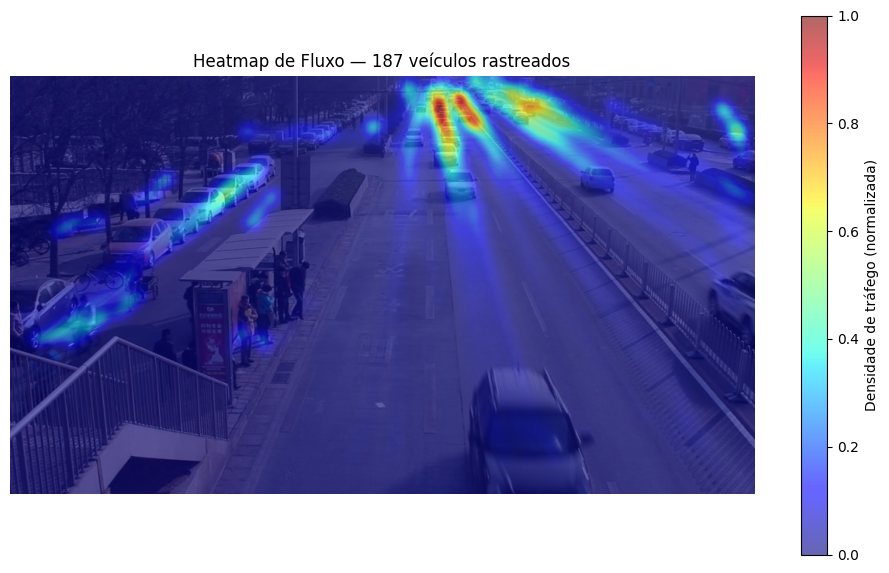

In [25]:
frame_base = cv2.imread(frames[0])
frame_base = cv2.cvtColor(frame_base, cv2.COLOR_BGR2RGB)

heatmap_norm = heatmap_fluxo_suave / heatmap_fluxo_suave.max()

plt.figure(figsize=(12, 7))
plt.imshow(frame_base)
plt.imshow(heatmap_norm, cmap="jet", alpha=0.6)
plt.axis("off")
plt.title(f"Heatmap de Fluxo — {len(trajetorias_validas)} veículos rastreados")
plt.colorbar(label="Densidade de tráfego (normalizada)")
plt.show()

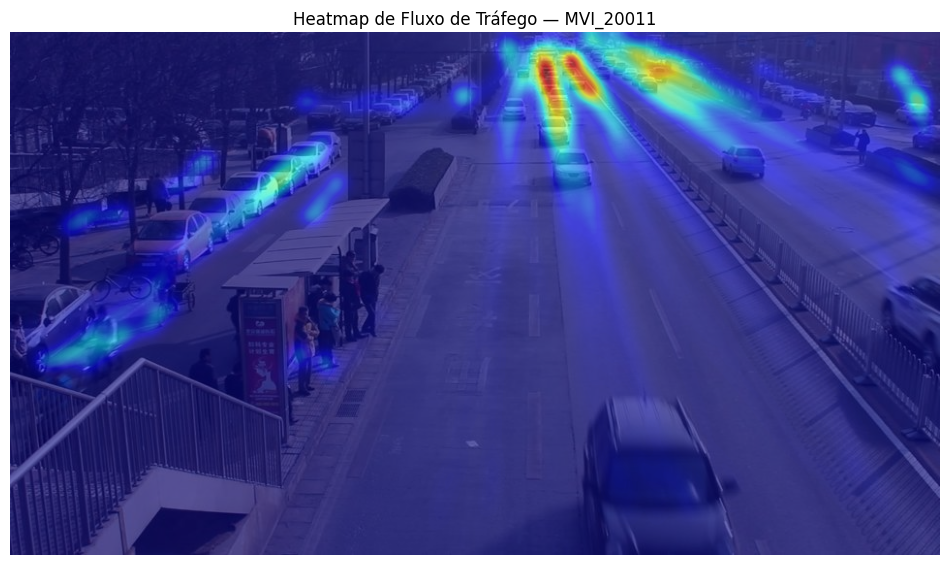

In [26]:
plt.figure(figsize=(12, 7))
plt.imshow(frame_base)
plt.imshow(heatmap_norm, cmap="jet", alpha=0.6)
plt.axis("off")
plt.title(f"Heatmap de Fluxo de Tráfego — MVI_20011")
plt.savefig("/content/heatmap_fluxo.png", dpi=200, bbox_inches="tight")
plt.show()

# Métricas de fluxo

## Contagem e direção

In [27]:
def direcao_principal(pts):
    coords = np.array([(x, y) for _, x, y in pts])
    dx, dy = coords[-1] - coords[0]
    angulo = math.degrees(math.atan2(dy, dx))  # -180 a 180
    return angulo

metricas = {}
for tid, pts in trajetorias_em_movimento.items():
    metricas[tid] = {
        "n_frames": len(pts),
        "direcao_graus": direcao_principal(pts),
    }

print(f"Total de veículos em movimento: {len(metricas)}")

Total de veículos em movimento: 69


## Velocidade

In [28]:
# Como descrito anteriormente, o FPS de gravação do UA-DETRAC é 25 FPS
FPS = 25

def velocidade_media(pts):
    coords = np.array([(x, y) for _, x, y in pts])
    deslocamentos = np.linalg.norm(np.diff(coords, axis=0), axis=1)
    return deslocamentos.mean()  # pixels por frame

for tid, pts in trajetorias_em_movimento.items():
    v_px_frame = velocidade_media(pts)
    metricas[tid]["velocidade_px_s"] = v_px_frame * FPS

In [29]:
df_metricas = pd.DataFrame.from_dict(metricas, orient="index")
df_metricas.index.name = "track_id"
print(df_metricas.describe())
df_metricas.head()

         n_frames  direcao_graus  velocidade_px_s
count   69.000000      69.000000        69.000000
mean   186.101449       8.952365        60.489687
std    123.399059     118.003812        26.880467
min     10.000000    -154.402740        13.348019
25%    132.000000    -139.570311        46.823925
50%    170.000000      55.072222        59.006209
75%    211.000000     100.012721        73.707441
max    664.000000     161.565162       175.434510


,n_frames,direcao_graus,velocidade_px_s
track_id,,,
1,72,71.752507,133.943497
2,92,-141.588672,36.184986
3,108,78.874468,96.689823
4,664,-100.681864,13.348019
7,664,-111.002811,14.344790


## Visualizar distribuição de direção e velocidade

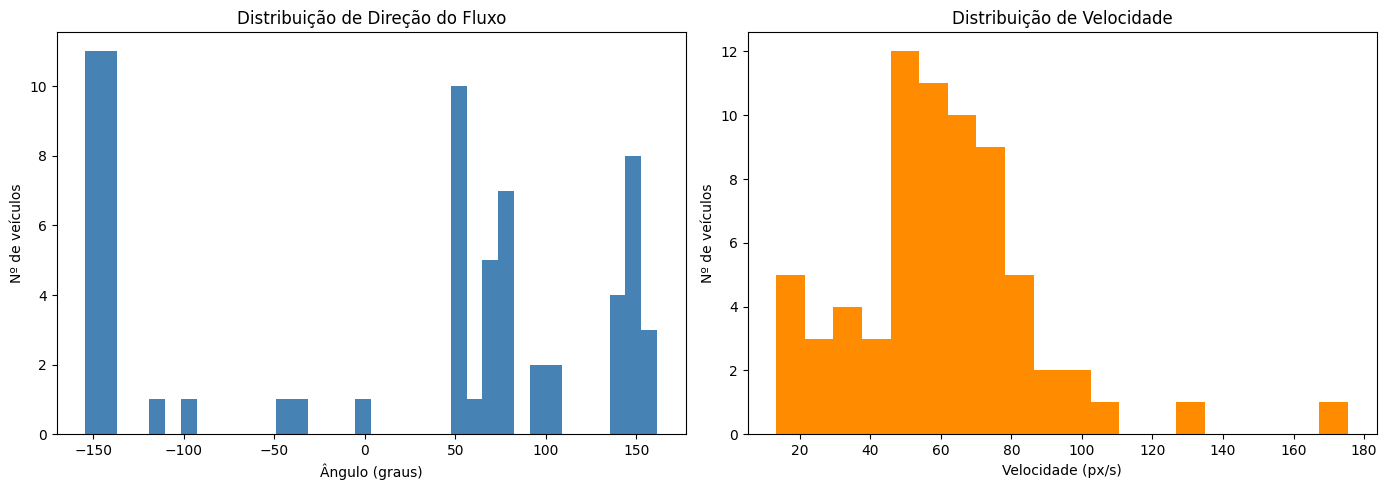

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Direção — rosa dos ventos simplificada
axes[0].hist(df_metricas["direcao_graus"], bins=36, color="steelblue")
axes[0].set_title("Distribuição de Direção do Fluxo")
axes[0].set_xlabel("Ângulo (graus)")
axes[0].set_ylabel("Nº de veículos")

# Velocidade
axes[1].hist(df_metricas["velocidade_px_s"], bins=20, color="darkorange")
axes[1].set_title("Distribuição de Velocidade")
axes[1].set_xlabel("Velocidade (px/s)")
axes[1].set_ylabel("Nº de veículos")

plt.tight_layout()
plt.savefig("/content/distribuicoes.png", dpi=200)
plt.show()